In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import os

### Merging 12 months of sales data into a single CSV file

In [2]:
df = pd.read_csv("./Sales_Data/Sales_January_2019.csv")
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


In [3]:
files = [file for file in os.listdir("./Sales_Data")]

all_data = pd.DataFrame()

for file in files:
    nr = file.split('.')[0]
    month = nr.split('_')[1]
    df = pd.read_csv('./Sales_Data/'+file)
    df['Month'] = month
    all_data = pd.concat([all_data, df], ignore_index = True) 

all_data.to_csv('Sales_2019.csv', index= False)

### Read in updates dataframe

In [4]:
sales_2019 = pd.read_csv('Sales_2019.csv')
sales_2019.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",April
1,NaN,NaN,NaN,NaN,NaN,NaN,April
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",April
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",April
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",April


In [5]:
sales_2019.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001",September
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016",September
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016",September
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016",September
186849,259357,USB-C Charging Cable,1,11.95,09/30/19 00:18,"250 Meadow St, San Francisco, CA 94016",September


### Clean up the data

In [6]:
sales_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
 6   Month             186850 non-null  object
dtypes: object(7)
memory usage: 10.0+ MB


In [9]:
sales_2019['Order Date'] = pd.to_datetime(sales_2019['Order Date'], format='%m/%d/%y %H:%M',errors='coerce')

In [13]:
sales_2019['Date'] = sales_2019['Order Date'].dt.date
date_col = sales_2019.pop('Date')
sales_2019.insert(5, 'Date', date_col)

In [14]:
sales_2019['Time'] = sales_2019['Order Date'].dt.time
time_col = sales_2019.pop('Time')
sales_2019.insert(6, 'Time', time_col)
sales_2019.sample(3)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Date,Time,Purchase Address,Month
8551,184728,Wired Headphones,1,11.99,2019-04-03 09:11:00,2019-04-03,09:11:00,"227 Center St, San Francisco, CA 94016",April
6037,182329,Wired Headphones,1,11.99,2019-04-20 17:43:00,2019-04-20,17:43:00,"704 Madison St, Boston, MA 02215",April
115044,171354,Bose SoundSport Headphones,1,99.99,2019-03-08 18:30:00,2019-03-08,18:30:00,"87 10th St, Boston, MA 02215",March


In [15]:
sales_2019['Price Each'] = pd.to_numeric(sales_2019['Price Each'], errors='coerce')

In [16]:
sales_2019['Quantity Ordered'] = pd.to_numeric(sales_2019['Quantity Ordered'], errors='coerce')

In [22]:
sales_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          186305 non-null  object        
 1   Product           186305 non-null  object        
 2   Quantity Ordered  185950 non-null  float64       
 3   Price Each        185950 non-null  float64       
 4   Order Date        185950 non-null  datetime64[ns]
 5   Date              185950 non-null  object        
 6   Time              185950 non-null  object        
 7   Purchase Address  186305 non-null  object        
 8   Month             186850 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 12.8+ MB


In [23]:
sales_2019.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    900
Price Each          900
Order Date          900
Date                900
Time                900
Purchase Address    545
Month                 0
dtype: int64

In [24]:
sales_2019 = sales_2019[sales_2019.notna().sum(axis=1) > 1] # Delete rows which have only one cell filled
sales_2019.isnull().sum()

Order ID              0
Product               0
Quantity Ordered    355
Price Each          355
Order Date          355
Date                355
Time                355
Purchase Address      0
Month                 0
dtype: int64

### Augment data with additional columns

#### Task1: add a sales column

In [27]:
sales_2019['Sales'] = sales_2019['Quantity Ordered'] * sales_2019['Price Each']
sales_2019.head()

C:\Users\majd9\AppData\Local\Temp\ipykernel_39616\183234169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_2019['Sales'] = sales_2019['Quantity Ordered'] * sales_2019['Price Each']


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Date,Time,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,2019-04-19,08:46:00,"917 1st St, Dallas, TX 75001",April,23.90
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,2019-04-07,22:30:00,"682 Chestnut St, Boston, MA 02215",April,99.99
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,2019-04-12,14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,600.00
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,2019-04-12,14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,11.99
5,176561,Wired Headphones,1.0,11.99,2019-04-30 09:27:00,2019-04-30,09:27:00,"333 8th St, Los Angeles, CA 90001",April,11.99


In [30]:
sales_col = sales_2019.pop('Sales')
sales_2019.insert(4, 'Sales', sales_col)
sales_2019.sample(3)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Purchase Address,Time,Month
35941,300945,Bose SoundSport Headphones,1.0,99.99,99.99,2019-12-12 11:28:00,2019-12-12,"463 Main St, Dallas, TX 75001",11:28:00,December
148234,289411,AAA Batteries (4-pack),1.0,2.99,2.99,2019-11-19 12:58:00,2019-11-19,"114 14th St, Los Angeles, CA 90001",12:58:00,November
53143,317395,Wired Headphones,1.0,11.99,11.99,2019-12-28 19:44:00,2019-12-28,"162 West St, Los Angeles, CA 90001",19:44:00,December


In [32]:
pur_col = sales_2019.pop('Purchase Address')
sales_2019.insert(9, 'Purchase Address', pur_col)
sales_2019.sample(3)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Month,Purchase Address
4234,180614,AAA Batteries (4-pack),1.0,2.99,2.99,2019-04-06 06:07:00,2019-04-06,06:07:00,April,"806 Chestnut St, Los Angeles, CA 90001"
74709,148049,Flatscreen TV,1.0,300.00,300.00,2019-01-17 20:45:00,2019-01-17,20:45:00,January,"558 South St, Portland, ME 04101"
140353,281890,LG Washing Machine,1.0,600.00,600.00,2019-11-16 01:01:00,2019-11-16,01:01:00,November,"46 Center St, Austin, TX 73301"


#### Task2: Divide Purchase Address column into 3 columns: Address Street, City, Zip Code

In [33]:
sales_2019[['Address Street', 'City', 'Zip Code']] = sales_2019['Purchase Address'].str.split(',', n=2, expand=True)
sales_2019.sample(3)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Month,Purchase Address,Address Street,City,Zip Code
135966,208828,Macbook Pro Laptop,1.0,1700.00,1700.00,2019-05-20 18:27:00,2019-05-20,18:27:00,May,"161 Elm St, San Francisco, CA 94016",161 Elm St,San Francisco,CA 94016
9228,185369,Lightning Charging Cable,1.0,14.95,14.95,2019-04-12 19:14:00,2019-04-12,19:14:00,April,"724 Ridge St, San Francisco, CA 94016",724 Ridge St,San Francisco,CA 94016
9371,185503,AA Batteries (4-pack),1.0,3.84,3.84,2019-04-11 19:37:00,2019-04-11,19:37:00,April,"363 6th St, San Francisco, CA 94016",363 6th St,San Francisco,CA 94016


In [35]:
sales_2019['State'] = sales_2019['Zip Code'].str[0:3]
sales_2019['Zip Code'] = sales_2019['Zip Code'].str[3:]
sales_2019.head(3)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Month,Purchase Address,Address Street,City,Zip Code,State
0,176558,USB-C Charging Cable,2.0,11.95,23.90,2019-04-19 08:46:00,2019-04-19,08:46:00,April,"917 1st St, Dallas, TX 75001",917 1st St,Dallas,001,75
2,176559,Bose SoundSport Headphones,1.0,99.99,99.99,2019-04-07 22:30:00,2019-04-07,22:30:00,April,"682 Chestnut St, Boston, MA 02215",682 Chestnut St,Boston,215,02
3,176560,Google Phone,1.0,600.00,600.00,2019-04-12 14:38:00,2019-04-12,14:38:00,April,"669 Spruce St, Los Angeles, CA 90001",669 Spruce St,Los Angeles,001,90


In [18]:
state_col = sales_2019.pop('State')
sales_2019.insert(10, 'State', state_col)
sales_2019.sample(3)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Month,Purchase Address,Address Street,City,State,Zip Code
62647,157302,Flatscreen TV,1.0,300.00,300.00,NaT,February,"297 Jefferson St, Portland, OR 97035",297 Jefferson St,Portland,OR,97035
96145,214199,Bose SoundSport Headphones,1.0,99.99,99.99,NaT,June,"671 2nd St, Portland, OR 97035",671 2nd St,Portland,OR,97035
72475,145916,Lightning Charging Cable,1.0,14.95,14.95,NaT,January,"7 5th St, Los Angeles, CA 90001",7 5th St,Los Angeles,CA,90001


#### Task3: Add Hour columns

In [37]:
sales_2019['Hour'] = sales_2019['Order Date'].dt.hour
hour_col = sales_2019.pop('Hour')
sales_2019.insert(8, 'Hour', hour_col)
sales_2019.sample(3)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Hour,Month,Purchase Address,Address Street,City,Zip Code,State
132862,205856,27in 4K Gaming Monitor,1.0,389.99,389.99,2019-05-19 21:02:00,2019-05-19,21:02:00,21.0,May,"587 4th St, Seattle, WA 98101",587 4th St,Seattle,101,98
99430,217345,Macbook Pro Laptop,1.0,1700.00,1700.00,2019-06-01 12:17:00,2019-06-01,12:17:00,12.0,June,"718 Main St, Seattle, WA 98101",718 Main St,Seattle,101,98
98793,216734,AA Batteries (4-pack),1.0,3.84,3.84,2019-06-18 21:22:00,2019-06-18,21:22:00,21.0,June,"70 5th St, San Francisco, CA 94016",70 5th St,San Francisco,016,94


### Q1: What was the best month for sales? How much was earned that month?

In [38]:
result = sales_2019.groupby('Month')['Sales'].sum().sort_values(ascending=False)
result

Month
December     4619297.12
October      3736884.05
April        3396059.11
November     3198909.23
May          3144584.80
March        2809063.30
July         2646899.69
June         2578293.30
August       2244412.31
February     2203481.24
September    2098816.70
January      1815335.12
Name: Sales, dtype: float64

C:\Users\majd9\AppData\Local\Temp\ipykernel_39616\466102494.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(result.index, rotation=45, ha='right')


Text(0.5, 0, 'Month')

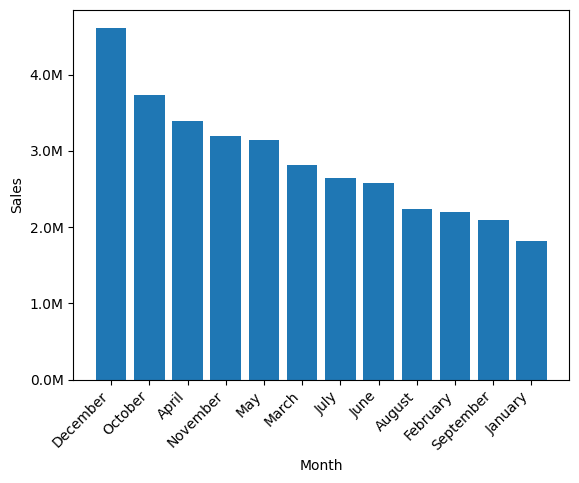

In [39]:
fig, ax = plt.subplots()
ax.bar(result.index, result.values)
def millions_formatter(x, pos): return f'{x/1e6:.1f}M'
ax.set_xticklabels(result.index, rotation=45, ha='right')
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax.set_ylabel('Sales')
ax.set_xlabel('Month')

### Q2: What city had the highest number of sales?

In [40]:
sales_2019.head(3)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Hour,Month,Purchase Address,Address Street,City,Zip Code,State
0,176558,USB-C Charging Cable,2.0,11.95,23.90,2019-04-19 08:46:00,2019-04-19,08:46:00,8.0,April,"917 1st St, Dallas, TX 75001",917 1st St,Dallas,001,75
2,176559,Bose SoundSport Headphones,1.0,99.99,99.99,2019-04-07 22:30:00,2019-04-07,22:30:00,22.0,April,"682 Chestnut St, Boston, MA 02215",682 Chestnut St,Boston,215,02
3,176560,Google Phone,1.0,600.00,600.00,2019-04-12 14:38:00,2019-04-12,14:38:00,14.0,April,"669 Spruce St, Los Angeles, CA 90001",669 Spruce St,Los Angeles,001,90


In [41]:
results = sales_2019.groupby(['City', 'State']).sum(numeric_only=True).sort_values(by='Sales', ascending=False)
results

,,Quantity Ordered,Price Each,Sales,Hour
City,State,,,,
San Francisco,94,50239.0,8211461.74,8262203.91,643265.0
Los Angeles,90,33289.0,5421435.23,5452570.80,427444.0
New York City,10,27932.0,4635370.83,4664317.43,357696.0
Boston,02,22528.0,3637409.77,3661642.01,288225.0
Atlanta,30,16602.0,2779908.20,2795498.58,214264.0
Dallas,75,16730.0,2752627.82,2767975.40,214390.0
Seattle,98,16553.0,2733296.01,2747755.48,213292.0
Portland,97,11303.0,1860558.22,1870732.34,144421.0
Austin,73,11153.0,1809873.61,1819581.75,141946.0


Text(0.5, 1.0, 'Sales per City')

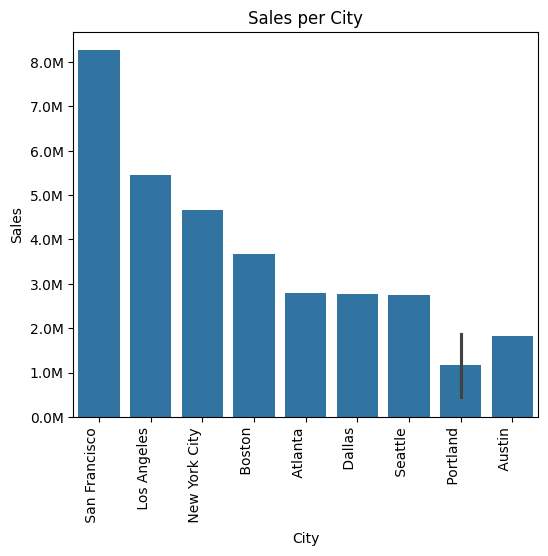

In [42]:
plt.figure(figsize=(6, 5))
ax = sns.barplot(data=results.reset_index(), x='City', y='Sales')
def millions_formatter(x, pos): return f'{x/1e6:.1f}M'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))
plt.xticks(rotation=90, ha='right')
plt.ylabel('Sales')
plt.xlabel('City')
plt.title('Sales per City')

### Q3: What time should we display advertisemens to maximize the likelihood of customer’s buying product?

In [43]:
sales_2019.sample(3)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Hour,Month,Purchase Address,Address Street,City,Zip Code,State
65076,159637,Bose SoundSport Headphones,1.0,99.99,99.99,2019-02-02 09:54:00,2019-02-02,09:54:00,9.0,February,"80 Meadow St, Austin, TX 73301",80 Meadow St,Austin,301,73
168461,272409,AA Batteries (4-pack),2.0,3.84,7.68,2019-10-27 06:11:00,2019-10-27,06:11:00,6.0,October,"494 Elm St, Los Angeles, CA 90001",494 Elm St,Los Angeles,001,90
8095,184285,Lightning Charging Cable,1.0,14.95,14.95,2019-04-23 08:41:00,2019-04-23,08:41:00,8.0,April,"505 Lake St, San Francisco, CA 94016",505 Lake St,San Francisco,016,94


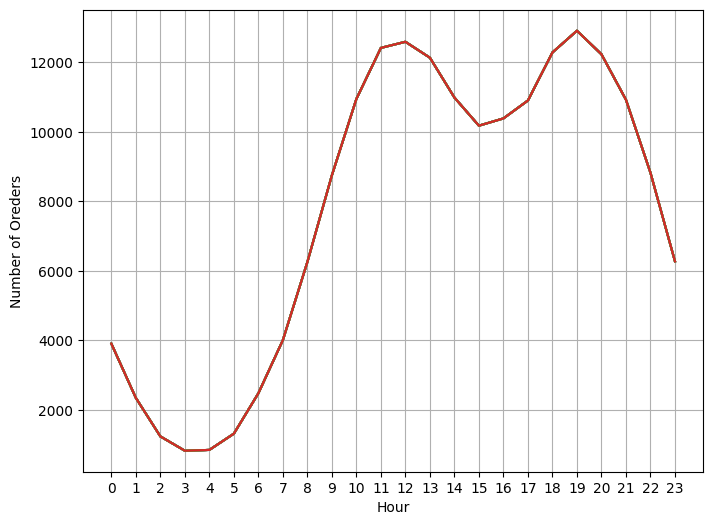

In [45]:
hours = [hour for hour, df in sales_2019.groupby('Hour')]

plt.figure(figsize=(8, 6))
plt.plot(hours, sales_2019.groupby('Hour').count())
plt.xticks(hours)
plt.xlabel('Hour')
plt.ylabel('Number of Oreders')
plt.grid()
plt.show()
# my recommendation around 11am or 7pm

### Q4: What products are most often sold together?

In [46]:
df = sales_2019[sales_2019['Order ID'].duplicated(keep=False)].copy()
df.head(12)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Hour,Month,Purchase Address,Address Street,City,Zip Code,State
3,176560,Google Phone,1.0,600.00,600.00,2019-04-12 14:38:00,2019-04-12,14:38:00,14.0,April,"669 Spruce St, Los Angeles, CA 90001",669 Spruce St,Los Angeles,001,90
4,176560,Wired Headphones,1.0,11.99,11.99,2019-04-12 14:38:00,2019-04-12,14:38:00,14.0,April,"669 Spruce St, Los Angeles, CA 90001",669 Spruce St,Los Angeles,001,90
18,176574,Google Phone,1.0,600.00,600.00,2019-04-03 19:42:00,2019-04-03,19:42:00,19.0,April,"20 Hill St, Los Angeles, CA 90001",20 Hill St,Los Angeles,001,90
19,176574,USB-C Charging Cable,1.0,11.95,11.95,2019-04-03 19:42:00,2019-04-03,19:42:00,19.0,April,"20 Hill St, Los Angeles, CA 90001",20 Hill St,Los Angeles,001,90
30,176585,Bose SoundSport Headphones,1.0,99.99,99.99,2019-04-07 11:31:00,2019-04-07,11:31:00,11.0,April,"823 Highland St, Boston, MA 02215",823 Highland St,Boston,215,02
31,176585,Bose SoundSport Headphones,1.0,99.99,99.99,2019-04-07 11:31:00,2019-04-07,11:31:00,11.0,April,"823 Highland St, Boston, MA 02215",823 Highland St,Boston,215,02
32,176586,AAA Batteries (4-pack),2.0,2.99,5.98,2019-04-10 17:00:00,2019-04-10,17:00:00,17.0,April,"365 Center St, San Francisco, CA 94016",365 Center St,San Francisco,016,94
33,176586,Google Phone,1.0,600.00,600.00,2019-04-10 17:00:00,2019-04-10,17:00:00,17.0,April,"365 Center St, San Francisco, CA 94016",365 Center St,San Francisco,016,94
119,176672,Lightning Charging Cable,1.0,14.95,14.95,2019-04-12 11:07:00,2019-04-12,11:07:00,11.0,April,"778 Maple St, New York City, NY 10001",778 Maple St,New York City,001,10
120,176672,USB-C Charging Cable,1.0,11.95,11.95,2019-04-12 11:07:00,2019-04-12,11:07:00,11.0,April,"778 Maple St, New York City, NY 10001",778 Maple St,New York City,001,10


In [47]:
df['Group Order by id'] = df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Hour,Month,Purchase Address,Address Street,City,Zip Code,State,Group Order by id
3,176560,Google Phone,1.0,600.00,600.00,2019-04-12 14:38:00,2019-04-12,14:38:00,14.0,April,"669 Spruce St, Los Angeles, CA 90001",669 Spruce St,Los Angeles,001,90,"Google Phone,Wired Headphones"
4,176560,Wired Headphones,1.0,11.99,11.99,2019-04-12 14:38:00,2019-04-12,14:38:00,14.0,April,"669 Spruce St, Los Angeles, CA 90001",669 Spruce St,Los Angeles,001,90,"Google Phone,Wired Headphones"
18,176574,Google Phone,1.0,600.00,600.00,2019-04-03 19:42:00,2019-04-03,19:42:00,19.0,April,"20 Hill St, Los Angeles, CA 90001",20 Hill St,Los Angeles,001,90,"Google Phone,USB-C Charging Cable"
19,176574,USB-C Charging Cable,1.0,11.95,11.95,2019-04-03 19:42:00,2019-04-03,19:42:00,19.0,April,"20 Hill St, Los Angeles, CA 90001",20 Hill St,Los Angeles,001,90,"Google Phone,USB-C Charging Cable"
30,176585,Bose SoundSport Headphones,1.0,99.99,99.99,2019-04-07 11:31:00,2019-04-07,11:31:00,11.0,April,"823 Highland St, Boston, MA 02215",823 Highland St,Boston,215,02,"Bose SoundSport Headphones,Bose SoundSport Hea..."


In [48]:
# delete duplicate rows
df = df[['Order ID', 'Group Order by id']].drop_duplicates()
df.head()

,Order ID,Group Order by id
3,176560,"Google Phone,Wired Headphones"
18,176574,"Google Phone,USB-C Charging Cable"
30,176585,"Bose SoundSport Headphones,Bose SoundSport Hea..."
32,176586,"AAA Batteries (4-pack),Google Phone"
119,176672,"Lightning Charging Cable,USB-C Charging Cable"


In [49]:
df.groupby('Group Order by id').count().sort_values(by='Order ID' ,ascending=False).head(10)

,Order ID
Group Order by id,
"iPhone,Lightning Charging Cable",882
"Google Phone,USB-C Charging Cable",856
"iPhone,Wired Headphones",361
"Vareebadd Phone,USB-C Charging Cable",312
"Google Phone,Wired Headphones",303
"iPhone,Apple Airpods Headphones",286
"Google Phone,Bose SoundSport Headphones",161
"Vareebadd Phone,Wired Headphones",104
"Google Phone,USB-C Charging Cable,Wired Headphones",77


In [50]:
from itertools import combinations
from collections import Counter

count = Counter()

for row in df['Group Order by id']:
    row_list = row.split(',')
    count.update(Counter(combinations(row_list, 2))) # most sold products together as 2 product together

for key, value in count.most_common(14):
    print(key, value)


('Product', 'Product') 62835
('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 160
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92
('Lightning Charging Cable', 'Apple Airpods Headphones') 81
('Vareebadd Phone', 'Bose SoundSport Headphones') 80
('USB-C Charging Cable', 'Bose SoundSport Headphones') 77


### Q5: What product sold the most? Why do you think it sold the most?

In [51]:
sales_2019.head()

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Date,Time,Hour,Month,Purchase Address,Address Street,City,Zip Code,State
0,176558,USB-C Charging Cable,2.0,11.95,23.90,2019-04-19 08:46:00,2019-04-19,08:46:00,8.0,April,"917 1st St, Dallas, TX 75001",917 1st St,Dallas,001,75
2,176559,Bose SoundSport Headphones,1.0,99.99,99.99,2019-04-07 22:30:00,2019-04-07,22:30:00,22.0,April,"682 Chestnut St, Boston, MA 02215",682 Chestnut St,Boston,215,02
3,176560,Google Phone,1.0,600.00,600.00,2019-04-12 14:38:00,2019-04-12,14:38:00,14.0,April,"669 Spruce St, Los Angeles, CA 90001",669 Spruce St,Los Angeles,001,90
4,176560,Wired Headphones,1.0,11.99,11.99,2019-04-12 14:38:00,2019-04-12,14:38:00,14.0,April,"669 Spruce St, Los Angeles, CA 90001",669 Spruce St,Los Angeles,001,90
5,176561,Wired Headphones,1.0,11.99,11.99,2019-04-30 09:27:00,2019-04-30,09:27:00,9.0,April,"333 8th St, Los Angeles, CA 90001",333 8th St,Los Angeles,001,90


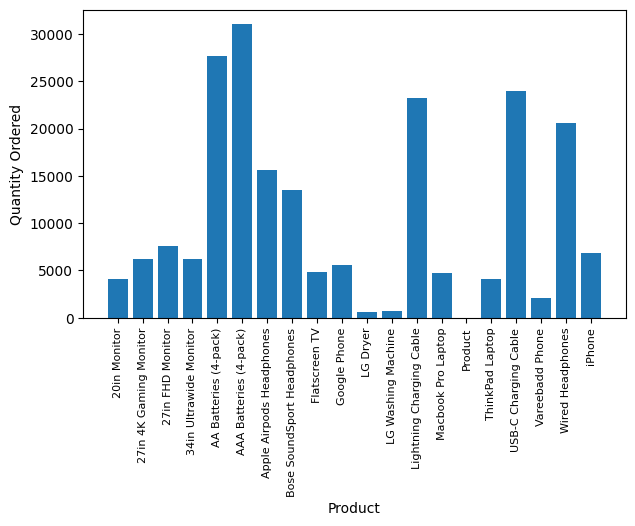

In [52]:
product_group = sales_2019.groupby('Product')

quantity_ordered = product_group.sum(numeric_only=True)['Quantity Ordered']
products = [product for product, df in product_group]

plt.figure(figsize=(7, 4))
plt.bar(products, quantity_ordered)
plt.xticks(products, rotation=90, size=8)
plt.xlabel('Product')
plt.ylabel('Quantity Ordered')
plt.show()

In [53]:
prices = sales_2019.groupby('Product')['Price Each'].mean()
prices

Product
20in Monitor                   109.99
27in 4K Gaming Monitor         389.99
27in FHD Monitor               149.99
34in Ultrawide Monitor         379.99
AA Batteries (4-pack)            3.84
AAA Batteries (4-pack)           2.99
Apple Airpods Headphones       150.00
Bose SoundSport Headphones      99.99
Flatscreen TV                  300.00
Google Phone                   600.00
LG Dryer                       600.00
LG Washing Machine             600.00
Lightning Charging Cable        14.95
Macbook Pro Laptop            1700.00
Product                           NaN
ThinkPad Laptop                999.99
USB-C Charging Cable            11.95
Vareebadd Phone                400.00
Wired Headphones                11.99
iPhone                         700.00
Name: Price Each, dtype: float64

C:\Users\majd9\AppData\Local\Temp\ipykernel_39616\427802153.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(products, rotation='vertical', size=8)


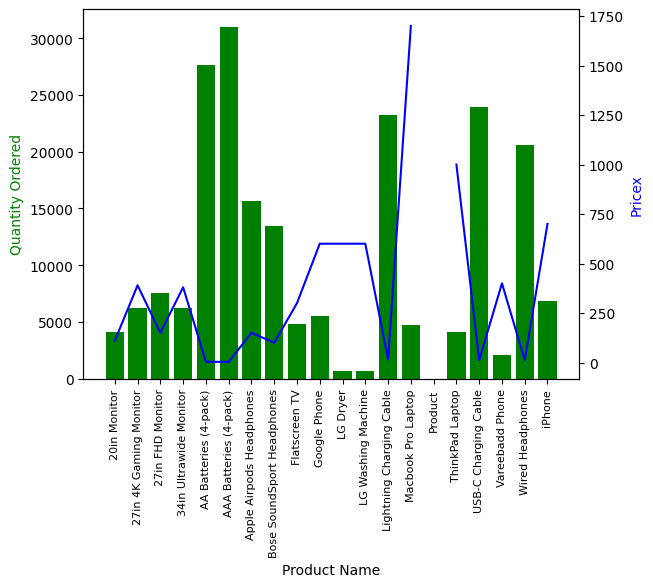

<Figure size 700x400 with 0 Axes>

In [54]:
fig, ax1 = plt.subplots()
plt.figure(figsize=(7, 4))

ax2 = ax1.twinx()
ax1.bar(products, quantity_ordered, color='g')
ax2.plot(products, prices, 'b-')
ax1.set_xticklabels(products, rotation='vertical', size=8)

ax1.set_xlabel('Product Name')
ax1.set_ylabel('Quantity Ordered', color='g')
ax2.set_ylabel('Pricex', color='b')

plt.show()